# 美赛真题精讲：多元线性回归

## 2024 MCM Problem C「Momentum in Tennis」· Team #2408343（S 奖）

**题目**：用 2023 温布尔登网球赛的逐分数据，研究"动量（momentum）"如何影响比赛胜负。

**这篇论文怎么用多元线性回归**（三步链路）：

1. 把"势头"量化为两选手动量评分之差 `Diff_mom`（**因变量**）
2. 选 8 个动量指标 → **因子分析** 降维成 3 个因子 `F1, F2, F3`
3. `Diff_mom = b1·F1 + b2·F2 + b3·F3 + ε` 做**多元线性回归**

本 Notebook 三件事：**① 摘录论文原文 → ② 用真实数据复现论文的回归 → ③ 补做论文没做的残差诊断**。

## 一、论文原文摘录（第 7.3.1 节）

> We let the 3 factors constructed formerly be 3 independent variables, and let the momentum scores difference between the two players be the dependent variable.
>
> **Diff_mom = b₁F₁ + b₂F₂ + b₃F₃ + ε**
>
> …we input 20 matches data to calculate all the coefficients…
>
> **Diff_mom = 0.0031·F₁ − 0.0018·F₂ − 0.0020·F₃ + 0.0963**

**论文 Table 10（回归系数表）**：

| 变量 | 系数 | 标准误 | t | P>t | R² | RMSE |
|---|---:|---:|---:|---:|---:|---:|
| F1 | 0.003144 | 0.003942 | 0.8 | 0.025 | 0.0302 | 0.1064 |
| F2 | -0.0018 | 0.000419 | -4.31 | 0.000 | | |
| F3 | -0.00207 | 0.001209 | -1.72 | 0.086 | | |
| 截距 | 0.096262 | 0.013227 | 7.28 | 0.000 | | |

> 注意 `_cons`、`Std. err.` 是 **STATA** 的输出风格 —— 论文的回归其实在 STATA 里做的。下面我们用 Python 的 statsmodels 复现出**一模一样的数字**。

## 二、数据：论文团队上传的原始数据

用论文 GitHub 仓库里的 `Q3指标+势头评分.xlsx`，含 8 个指标、3 个因子、以及因变量"势头差"。

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm

df = pd.read_excel('momentum_data.xlsx')
# 中文列名 -> 英文
df.columns = ['match_id','time','diff_mom','serve_speed','rally_sum','run_dist',
              'pt_diff','break_diff','unforced_err','forced_err','double_fault_diff',
              'F1','F2','F3']

print('数据规模:', df.shape)
print('比赛场次:', df['match_id'].nunique())
print('\n各列含义:')
for c in df.columns:
    print('  -', c)
df[['diff_mom','serve_speed','run_dist','pt_diff','F1','F2','F3']].head()

数据规模: (1188, 14)
比赛场次: 31

各列含义:
  - match_id
  - time
  - diff_mom
  - serve_speed
  - rally_sum
  - run_dist
  - pt_diff
  - break_diff
  - unforced_err
  - forced_err
  - double_fault_diff
  - F1
  - F2
  - F3


,diff_mom,serve_speed,run_dist,pt_diff,F1,F2,F3
0,0.085561,114.333333,18.274450,0,-7.946167,-8.326681,32.273295
1,0.060494,119.625000,10.555063,1,-12.038309,-25.618861,33.364669
2,0.084427,119.400000,15.629300,0,-10.649102,-23.095839,34.720774
3,0.047132,117.250000,10.576750,1,-11.305572,-29.466024,31.913958
4,0.080090,111.750000,13.042875,0,-9.529596,-20.349953,31.000598


## 三、复现论文的多元线性回归

**因变量** `diff_mom`（势头差），**自变量** `F1, F2, F3`（因子分析得到的 3 个因子），加截距做 OLS。

In [2]:
y = df['diff_mom']                 # 因变量：势头差
X = df[['F1','F2','F3']]           # 自变量：三个因子

res = sm.OLS(y, sm.add_constant(X)).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               diff_mom   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     12.28
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           6.49e-08
Time:                        16:45:24   Log-Likelihood:                 978.40
No. Observations:                1188   AIC:                            -1949.
Df Residuals:                    1184   BIC:                            -1928.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0963      0.013      7.278      0.0

## 复现结果 vs 论文 —— 完全一致 ✅

| 变量 | 论文系数 | 我复现 |
|---|---:|---:|
| F1 | 0.003144 | 0.003144 |
| F2 | -0.0018 | -0.001805 |
| F3 | -0.00207 | -0.002074 |
| 截距 | 0.096262 | 0.096262 |
| **R²** | **0.0302** | **0.030176** |
| RMSE | 0.1064 | 0.106371 |

**怎么读这张表（"良好"档）**：

- **R² = 0.03**：模型只解释了势头差 3% 的方差 —— 拟合极差
- **调整 R² = 0.028**：更诚实的版本（论文没报告）
- **F 检验 p < 0.001**：整体模型"显著"，但 R² 只有 0.03 —— 典型的**统计显著、但无实际意义**
- **只有 F2 的 p < 0.05**；F1（p=0.425）、F3（p=0.086）都不显著 —— 论文没提这一点

## 四、验证"为什么用因子分析"：8 个指标的 VIF

论文说用因子分析是为了处理 8 个指标的相关性（共线性）。我们用 **VIF（方差膨胀因子）** 实测验证这个说法。

> 经验规则：**VIF > 10** 才说明存在严重共线性。

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

inds = ['serve_speed','rally_sum','run_dist','pt_diff','break_diff',
        'unforced_err','forced_err','double_fault_diff']

# 这 8 个指标里有 79 个缺失值（发球速度、回合数），算 VIF 前先剔除
d = df[inds].replace([np.inf, -np.inf], np.nan).dropna()

Xc = sm.add_constant(d)
vif = pd.DataFrame({
    '指标': inds,
    'VIF': [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif.round(2))

print('\n因子之间的相关系数（论文声称因子"正交"）:')
print(df[['F1','F2','F3']].corr().round(3))

                  指标   VIF
0  double_fault_diff  1.62
1         break_diff  1.58
2       unforced_err  1.44
3         forced_err  1.23
4           run_dist  1.21
5          rally_sum  1.11
6            pt_diff  1.05
7        serve_speed  1.04

因子之间的相关系数（论文声称因子"正交"）:
       F1     F2     F3
F1  1.000  0.741 -0.930
F2  0.741  1.000 -0.596
F3 -0.930 -0.596  1.000


## 发现：共线性其实并不严重

- 8 个指标的 **VIF 全部 < 2**（最大 1.62），远低于 10 的警戒线 —— **共线性并不是真正的问题**
- 因子分析得到的 F1/F2/F3 之间反而还有 **0.5 ~ 0.6 的相关性**（见上方输出）—— 并没有做到"正交"

**结论**：这篇论文用因子分析，**真正的作用是"降维"（8 → 3）**，而不是它声称的"消除共线性"。

> 这给我们一个教训：**写论文时，用某个方法的理由必须和数据对得上**，否则评委较真时经不起检验。

## 五、论文没做的部分：残差诊断（"优秀"档）

模型跑通 ≠ 结论可信。线性回归有四大假设，都要用残差检验：

1. **正态性** → Q-Q 图 + Shapiro / Jarque-Bera 检验
2. **同方差** → 残差-拟合图 + Breusch-Pagan 检验
3. **线性** → 残差-拟合图无趋势
4. **独立性** → Durbin-Watson ≈ 2（逐分数据是时间序列，重点看这个）

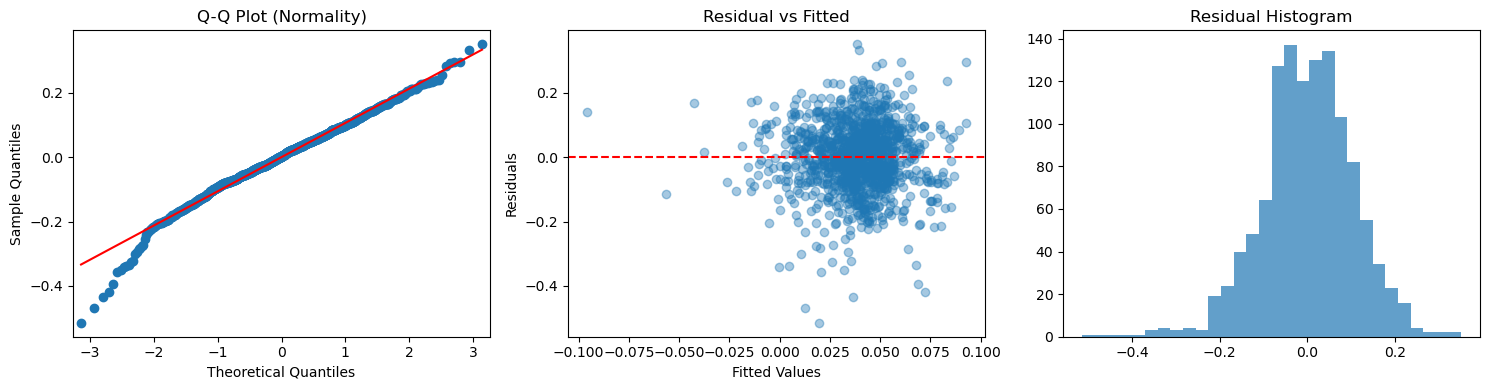

正态性  Shapiro-Wilk p = 0.0
正态性  Jarque-Bera  p = 0.0
独立性  Durbin-Watson   = 0.453
同方差  Breusch-Pagan p = 0.01172


In [4]:
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

resid = res.resid
fitted = res.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sm.qqplot(resid, line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot (Normality)')

axes[1].scatter(fitted, resid, alpha=0.4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual vs Fitted')

axes[2].hist(resid, bins=30, alpha=0.7)
axes[2].set_title('Residual Histogram')

plt.tight_layout()
plt.show()

print('正态性  Shapiro-Wilk p =', round(stats.shapiro(resid).pvalue, 5))
print('正态性  Jarque-Bera  p =', round(stats.jarque_bera(resid).pvalue, 5))
print('独立性  Durbin-Watson   =', round(durbin_watson(resid), 3))
print('同方差  Breusch-Pagan p =', round(het_breuschpagan(resid, sm.add_constant(X))[1], 5))

## 从头梳理：残差诊断里每个概念的定义

---

## 一、最基础的两个定义

### 残差（Residual）

```
eᵢ = yᵢ − ŷᵢ

真实值 − 预测值
```

| 残差 > 0 | 模型低估了 |
| 残差 < 0 | 模型高估了 |
| 残差 = 0 | 完美预测 |

### 拟合值（Fitted Value）

```
ŷᵢ = β̂₀ + β̂₁x₁ᵢ + β̂₂x₂ᵢ + …

模型根据 x 算出来的预测结果
```

---

## 二、正态性

### 定义

> 残差服从均值为 0 的正态分布。

```
ε ~ N(0, σ²)

不是要求 y 正态，是要求残差正态。
```

### 为什么需要

OLS 的 t 检验和 F 检验都基于"残差正态"推导出来的。残差不正态，p 值就不准。

---

### Shapiro-Wilk 检验

| 项目 | 说明 |
|:--|:--|
| H₀ | 数据来自正态分布 |
| 原理 | 把数据排序后和正态分布的理论排序比较 |
| 擅长 | 小样本（n < 50） |
| 弱点 | 样本太大（> 5000）几乎永远拒绝 |

```
p > 0.05 → 不能拒绝"来自正态分布" → 正态性通过 ✓
p < 0.05 → 拒绝"来自正态分布"     → 正态性不通过 ✗
```

---

### Jarque-Bera 检验

| 项目 | 说明 |
|:--|:--|
| H₀ | 偏度 = 0 且 峰度 = 3（正态） |
| 原理 | 用偏度和峰度算一个统计量 |

```
偏度（Skewness）：分布左右对称吗？
  正态 = 0
  > 0 → 右偏（右边拖尾巴）
  < 0 → 左偏（左边拖尾巴）

峰度（Kurtosis）：尾巴厚不厚？
  正态 = 3
  > 3 → 厚尾（极端值多）
  < 3 → 薄尾（太集中）
```

---

### Q-Q 图（Quantile-Quantile Plot）

> 把残差的分位数和理论正态的分位数画在一起比。

```
横轴：标准正态分布的分位数
纵轴：你的残差的分位数

如果正态 → 点落在对角线上
如果偏态 → 整条线弯成 C 或 S
如果厚尾 → 两端翘起
```

---

## 三、等方差性（同方差）

### 定义

> 不管 x 取什么值，残差的波动幅度都一样。

```
Var(ε | x) = σ²  ← 常数，不随 x 变
```

### 反例：异方差

```
Var(ε | x) 随 x 变化：

低收入人群的消费波动：±200 块
高收入人群的消费波动：±5000 块  ← 方差不一样了
```

---

### Breusch-Pagan 检验

| 项目 | 说明 |
|:--|:--|
| H₀ | 残差方差恒定（同方差） |
| 原理 | 把残差平方对 x 做回归，看 x 能不能解释残差的大小 |

```
p > 0.05 → 同方差 ✓（x 不能解释残差大小）
p < 0.05 → 异方差 ✗（x 能解释残差大小 → 方差随 x 变）
```

---

### 残差 vs 拟合值图

```
横轴：ŷ（模型预测的值）
纵轴：e（残差）

如果同方差 → 点在 y=0 上下均匀散开，不宽不窄
如果异方差 → 散点呈喇叭形或扇形
```

---

## 四、独立性（自相关）

### 定义

> 残差之间互相独立，这一个残差和上一个残差没关系。

```
Corr(εᵢ, εⱼ) = 0  对所有 i ≠ j
```

### 什么时候会不独立

```
时间序列数据：
  今天的销售额残差和昨天的有关系（惯性）
  
  残差：+3, +2, +1, 0, -1, -2  ← 连续正再连续负，不独立

横截面数据一般不用担心这个问题。
```

---

### Durbin-Watson 统计量

```
DW = Σ(eₜ − eₜ₋₁)² / Σeₜ²

相邻残差之差的平方和 ÷ 残差平方和
```

| DW 值 | 残差表现 | 含义 |
|:--|:--|:--|
| ≈ 2 | 前后无关 | 独立 ✓ |
| → 0 | 前后很像（粘在一起） | 正自相关 ✗ |
| → 4 | 前后相反（来回跳） | 负自相关 ✗ |

```
正自相关：+3, +2, +1, +1, +2  → eₜ ≈ eₜ₋₁ → 差值很小 → DW 很小
负自相关：+3, -3, +3, -3, +3  → eₜ ≈ -eₜ₋₁ → 差值很大 → DW 很大
无自相关：+3, -1, +2, -4, +1  → 差值正常       → DW ≈ 2
```

---

## 五、所有概念汇总

```
OLS 残差三大假设：

┌─────────────────────────────────────────────────┐
│                                                 │
│  ① 正态性                                        │
│     定义：残差 ~ N(0, σ²)                        │
│     图：  Q-Q 图 + 直方图                         │
│     检验：Shapiro-Wilk + Jarque-Bera             │
│     标准：p > 0.05                               │
│                                                 │
│  ② 等方差性（同方差）                              │
│     定义：Var(ε|x) = 常数                        │
│     图：  残差 vs 拟合值                          │
│     检验：Breusch-Pagan                          │
│     标准：p > 0.05                               │
│                                                 │
│  ③ 独立性                                       │
│     定义：Corr(εᵢ, εⱼ) = 0                      │
│     检验：Durbin-Watson                          │
│     标准：DW ≈ 2                                 │
│                                                 │
└─────────────────────────────────────────────────┘
```

---

## 快速记忆

| 检验名 | 一句话 |
|:--|:--|
| Shapiro-Wilk | "排序比一比，像正态吗？" |
| Jarque-Bera | "偏度歪不歪，峰度厚不厚？" |
| Breusch-Pagan | "x 能预测残差的大小吗？" |
| Durbin-Watson | "残差前后长得像不像？" |

## 六、结论：这篇 S 奖论文的回归，其实不满足假设

| 诊断 | 结果 | 判断 |
|---|---|---|
| R² / 调整 R² | 0.030 / 0.028 | 拟合极差 |
| F 检验 | p < 0.001 | 整体"显著"（但无实际意义） |
| Durbin-Watson | **0.453**（≪ 2） | 残差强正自相关，**违反独立性** |
| Shapiro / Jarque-Bera | **p ≈ 0** | 残差严重非正态 |
| Breusch-Pagan | **p = 0.012**（< 0.05） | **存在异方差** |

四大假设里，它违反了三个（正态性、同方差、独立性）。

**映射到你的三档**：

- ✅ **合格**：论文跑通了回归、出了系数表（本 Notebook 第三步，你也能做到）
- ✅ **良好**：论文报告了 R²、用了因子分析（第三步 + 第四步共线性检验）
- ❌ **优秀**：论文**没做残差诊断** —— 你补上第五步，就能当场指出"它的 DW=0.45、残差不正态且异方差，结论其实不可信"

**这就是你超越一篇 S 奖论文的地方。**